In [3]:
import pandas as pd
import scipy.io

dir = 'mni_coord_norm_multi/'
radius = 5



fs_dict = {
    "js01": "JS1_FT",
    "js02": "JS2_FT",
    "js04": "JS4_FT",
    "js05": "JS5_FT",
    # "js06": "JS6_FT",
    "js07": "JS7_FT",
    "js08": "JS8_FT",
    # "js09": "JS9_FT",
    # "js10": "J20003_YN",
    "js11": "J20004_HM",
    # "js12": "J21001_TT",
    "js13": "J21002_SK",
    "js14": "J21003_MM",
    "js15": "J21005_MH",
    "js16": "J21008_SS",
}

df_list = []
for js in fs_dict.keys():
    mni_file = f"{dir}/sub-{js}_mni.mat"
    # aal_label_file = f"{dir}/sub-{js}_AALlabel.mat"
    aal_label_file = f"{dir}/sub-{js}_AALlabel_multiple{radius}.mat"
    
    mni_data = scipy.io.loadmat(mni_file)
    aal_label_data = scipy.io.loadmat(aal_label_file)
    ch_pos = mni_data['elec_mni_frv'][0][0][0] / 1000  # メートル単位に変換
    
    aal_label = aal_label_data['AALlabel']
    
    # チャンネル名を生成
    ch_names = [f"ch{i:02d}" for i in range(1, len(ch_pos) + 1)]
    
    # ラベルを取得（配列から文字列として抽出）
    labels = []
    for i in range(len(aal_label)):
        label = aal_label[i][1].item() if hasattr(aal_label[i][1], 'item') else str(aal_label[i][1])
        labels.append(label)
    
    # DataFrameを作成
    df = pd.DataFrame({
        'x': ch_pos[:, 0],
        'y': ch_pos[:, 1],
        'z': ch_pos[:, 2],
        'label': labels,
        'sub': js
    }, index=ch_names)

    df_list.append(df)
    print(f"Subject {js}:")
    print(df.head(10))
    print(f"\nTotal channels: {len(df)}")


all_df = pd.concat(df_list)
# all_df.to_csv('all_coord_label.csv', index=False)
all_df

Subject js01:
             x         y         z                 label   sub
ch01 -0.013797 -0.049520  0.053301           Precuneus_L  js01
ch02 -0.010444 -0.049628  0.057675           Precuneus_L  js01
ch03 -0.012236 -0.054193  0.048475           Precuneus_L  js01
ch04 -0.007928 -0.054147  0.052827           Precuneus_L  js01
ch05 -0.004637 -0.027661  0.075573  Paracentral_Lobule_L  js01
ch06 -0.004527 -0.033621  0.074072  Paracentral_Lobule_L  js01
ch07 -0.004027 -0.038435  0.071830  Paracentral_Lobule_L  js01
ch08 -0.003541 -0.043461  0.070408           Precuneus_L  js01
ch09 -0.046172  0.002323  0.056231          Precentral_L  js01
ch10 -0.046657 -0.010345  0.059823          Precentral_L  js01

Total channels: 80
Subject js02:
             x         y         z          label   sub
ch01  0.031048  0.002035  0.047567  Frontal_Mid_R  js02
ch02  0.030740 -0.002561  0.049104   Precentral_R  js02
ch03  0.027520 -0.002497  0.043614   Precentral_R  js02
ch04  0.029957 -0.005143  0.048102 

,x,y,z,label,sub
ch01,-0.013797,-0.049520,0.053301,Precuneus_L,js01
ch02,-0.010444,-0.049628,0.057675,Precuneus_L,js01
ch03,-0.012236,-0.054193,0.048475,Precuneus_L,js01
ch04,-0.007928,-0.054147,0.052827,Precuneus_L,js01
ch05,-0.004637,-0.027661,0.075573,Paracentral_Lobule_L,js01
...,...,...,...,...,...
ch36,-0.036872,0.012869,0.035202,Frontal_Mid_L,js16
ch37,-0.042078,0.013788,0.033887,Frontal_Inf_Oper_L,js16
ch38,-0.045674,0.012042,0.035994,Frontal_Mid_L,js16
ch39,-0.044171,0.017452,0.033812,Frontal_Inf_Oper_L,js16


In [4]:
all_df[all_df['label'] == 'no_label_found']

,x,y,z,label,sub
ch39,-0.043887,-0.014891,-0.041149,no_label_found,js04
ch35,-0.040781,-0.016891,-0.042266,no_label_found,js05
ch36,-0.047430,-0.012397,-0.043568,no_label_found,js05
ch25,-0.005095,0.043051,-0.031683,no_label_found,js11
ch79,-0.041467,-0.002456,-0.047962,no_label_found,js15
ch26,-0.027411,0.004659,0.025641,no_label_found,js16
ch30,-0.026601,0.021003,0.020514,no_label_found,js16
ch31,-0.030883,0.020321,0.025497,no_label_found,js16
ch34,-0.022104,0.010413,0.029936,no_label_found,js16


/var/folders/t_/5rdh_lpn3r34351h6lbs9nq80000gn/T/ipykernel_78714/3309954790.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap('tab20', len(unique_regions))
/var/folders/t_/5rdh_lpn3r34351h6lbs9nq80000gn/T/ipykernel_78714/3309954790.py:32: UserWarning: Glyph 12392 (\N{HIRAGANA LETTER TO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/t_/5rdh_lpn3r34351h6lbs9nq80000gn/T/ipykernel_78714/3309954790.py:32: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/t_/5rdh_lpn3r34351h6lbs9nq80000gn/T/ipykernel_78714/3309954790.py:32: UserWarning: Glyph 23550 (\N{CJK UNIFIED IDEOGRAPH-5BFE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/t_/5rdh_lpn3r34351h6lbs9nq80000gn/T/ipykernel_78

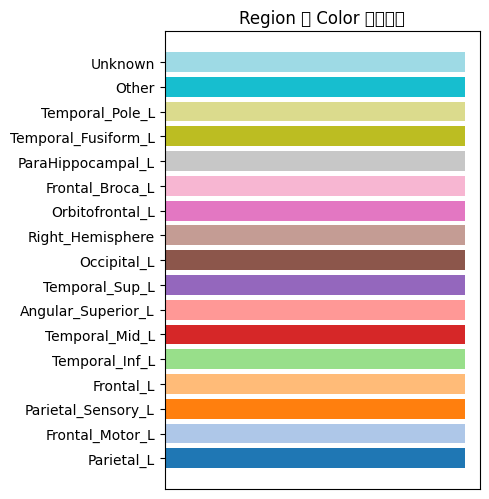

In [5]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import yaml

# YAMLファイルからマッピングを読み込む
with open('region_map/aal_lobe_mapping_speech.yaml', 'r', encoding='utf-8') as f:
    mapping_data = yaml.safe_load(f)
aal_to_anatomical_group = mapping_data['aal_to_lobe']

ch_pos = all_df[['x', 'y', 'z']].values

all_df['region'] = all_df['label'].map(aal_to_anatomical_group)

# region列のカテゴリごとに適当に色決め
unique_regions = all_df['region'].unique()
# matplotlibのカラーマップを利用して色を割り当て
cmap = matplotlib.cm.get_cmap('tab20', len(unique_regions))
region_colors = {reg: matplotlib.colors.rgb2hex(cmap(i)) for i, reg in enumerate(unique_regions)}
all_df['color'] = all_df['region'].map(region_colors)
all_df.loc[all_df['region'] == 'Unknown', 'color'] = 'gray'
colors = all_df['color'].tolist()

# regionとcolorsの対応の図を作成
fig, ax = plt.subplots(figsize=(5, max(5, len(unique_regions)*0.3)))
for idx, reg in enumerate(unique_regions):
    ax.barh(idx, 1, color=region_colors[reg])
ax.set_yticks(np.arange(len(unique_regions)))
ax.set_yticklabels(unique_regions)
ax.set_xticks([])
ax.set_title("Region と Color の対応図")
plt.tight_layout()
plt.show()

all_df.to_csv(f"all_coord_multi5_and_region_speech.csv")
# all_df

In [8]:
len(aal_to_anatomical_group.keys())
len(all_df['region'].unique())

17